# Step 5 — Results Synthesis, Diagnostics, and Final Discussion


## 1. Imports


In [1]:
# %pip install scikit-learn joblib pandas numpy matplotlib

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import joblib

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score


## 2. Configuration


In [2]:
TICKERS = ["AAPL", "MSFT", "NVDA", "TSLA"]

PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../data/models")
OUTPUT_DIR = Path("../data/final")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TEST_FRACTION = 0.2          # must match Step 4
WALKFORWARD_SPLITS = 5       # must match Step 4

NUMERIC_FEATURES = [
    "Open", "High", "Low", "Close", "Adj_Close", "Volume", "Return",
    "Sentiment_Mean", "Sentiment_Std", "Headline_Count",
    "SMA_5", "SMA_10", "EMA_5", "EMA_10", "Price_to_SMA10", "RSI_14",
    "MACD", "MACD_Signal", "MACD_Hist", "Volatility_5", "Momentum_5", "Volume_Change"
]

print("Processed data directory:", PROCESSED_DIR.resolve())
print("Models directory:", MODELS_DIR.resolve())
print("Final output directory:", OUTPUT_DIR.resolve())


Processed data directory: D:\Projects\stock-market-prediction\data\processed
Models directory: D:\Projects\stock-market-prediction\data\models
Final output directory: D:\Projects\stock-market-prediction\data\final


## 3. Load Step 3 and Step 4 Outputs


In [3]:
data = pd.read_parquet(PROCESSED_DIR / "final_combined_dataset.parquet")
data["Date"] = pd.to_datetime(data["Date"])
data = data.sort_values(["Ticker", "Date"]).reset_index(drop=True)

news_scored = pd.read_parquet(PROCESSED_DIR / "financial_news_scored.parquet")

results_df = pd.read_csv(MODELS_DIR / "model_comparison_results_v3.csv", index_col="Model")
confidence_df = pd.read_csv(MODELS_DIR / "confidence_threshold_results_v3.csv", index_col="Model")
test_predictions = pd.read_csv(MODELS_DIR / "test_set_predictions_v3.csv", parse_dates=["Date"])

feature_names = joblib.load(MODELS_DIR / "feature_names_v3.joblib")
scaler = joblib.load(MODELS_DIR / "feature_scaler_v3.joblib")

trained_models = {}
for path in MODELS_DIR.glob("model_v3_*.joblib"):
    name = path.stem.replace("model_v3_", "").replace("_", " ").title()
    if name == "Xgboost":
        name = "XGBoost"
    trained_models[name] = joblib.load(path)

print("Final dataset shape:", data.shape)
print("Scored news shape:", news_scored.shape)
print("Loaded models:", list(trained_models.keys()))
print("\nStep 4 test-set results (for reference):")
display(results_df)


Final dataset shape: (3016, 12)
Scored news shape: (28699, 8)
Loaded models: ['Logistic Regression', 'Random Forest', 'XGBoost']

Step 4 test-set results (for reference):


,CV Accuracy,Test Accuracy,Precision,Recall,F1
Model,,,,,
Majority-Class Baseline,NaN,0.547,0.547,1.000,0.707
Logistic Regression,0.495,0.515,0.559,0.530,0.545
Random Forest,0.500,0.495,0.530,0.671,0.592
XGBoost,0.512,0.475,0.524,0.430,0.472


## 4. Rebuild Features and the Train/Test Split


In [4]:
def add_indicators(group):
    group = group.sort_values("Date").copy()

    group["Return"] = group["Close"].pct_change()

    group["SMA_5"] = group["Close"].rolling(5, min_periods=1).mean()
    group["SMA_10"] = group["Close"].rolling(10, min_periods=1).mean()
    group["EMA_5"] = group["Close"].ewm(span=5, adjust=False).mean()
    group["EMA_10"] = group["Close"].ewm(span=10, adjust=False).mean()
    group["Price_to_SMA10"] = group["Close"] / group["SMA_10"] - 1

    delta = group["Close"].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(14, min_periods=1).mean()
    avg_loss = loss.rolling(14, min_periods=1).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    group["RSI_14"] = (100 - (100 / (1 + rs))).fillna(50.0)

    ema_12 = group["Close"].ewm(span=12, adjust=False).mean()
    ema_26 = group["Close"].ewm(span=26, adjust=False).mean()
    group["MACD"] = ema_12 - ema_26
    group["MACD_Signal"] = group["MACD"].ewm(span=9, adjust=False).mean()
    group["MACD_Hist"] = group["MACD"] - group["MACD_Signal"]

    group["Volatility_5"] = group["Return"].rolling(5, min_periods=1).std().fillna(0.0)
    group["Momentum_5"] = group["Close"] - group["Close"].shift(5)
    group["Momentum_5"] = group["Momentum_5"].fillna(0.0)
    group["Volume_Change"] = group["Volume"].pct_change()

    next_close = group["Close"].shift(-1)
    group["Direction"] = (next_close > group["Close"]).astype("float")
    group.loc[next_close.isna(), "Direction"] = np.nan

    return group

frames = []
for ticker in TICKERS:
    group = data[data["Ticker"] == ticker].copy()
    group = add_indicators(group)
    frames.append(group)

data = pd.concat(frames, ignore_index=True)
data = data.dropna(subset=["Return", "Volume_Change", "Direction"]).reset_index(drop=True)
data["Direction"] = data["Direction"].astype(int)


def build_features(df):
    X = df[NUMERIC_FEATURES].copy()
    ticker_dummies = pd.get_dummies(df["Ticker"], prefix="Ticker")
    return pd.concat([X.reset_index(drop=True), ticker_dummies.reset_index(drop=True)], axis=1)


train_frames, test_frames = [], []
for ticker in TICKERS:
    ticker_data = data[data["Ticker"] == ticker].sort_values("Date")
    n_test = max(1, int(round(len(ticker_data) * TEST_FRACTION)))
    train_frames.append(ticker_data.iloc[:-n_test])
    test_frames.append(ticker_data.iloc[-n_test:])

train_df = pd.concat(train_frames).sort_values("Date").reset_index(drop=True)
test_df = pd.concat(test_frames).sort_values(["Ticker", "Date"]).reset_index(drop=True)

X_train_raw = build_features(train_df)
X_test_raw = build_features(test_df).reindex(columns=X_train_raw.columns, fill_value=0)

y_train = train_df["Direction"].values
y_test = test_df["Direction"].values

# Reuse the SAVED scaler (already fit in Step 4) -- do not refit here
X_train_scaled = scaler.transform(X_train_raw[NUMERIC_FEATURES])
X_test_scaled = scaler.transform(X_test_raw[NUMERIC_FEATURES])

X_train = np.concatenate([X_train_scaled, X_train_raw.drop(columns=NUMERIC_FEATURES).values], axis=1)
X_test = np.concatenate([X_test_scaled, X_test_raw.drop(columns=NUMERIC_FEATURES).values], axis=1)

print("Train shape:", X_train.shape, " | Test shape:", X_test.shape)
assert list(X_train_raw.drop(columns=NUMERIC_FEATURES).columns) == \
       [c for c in feature_names if c not in NUMERIC_FEATURES], \
       "Rebuilt feature columns do not match Step 4's saved feature_names -- stop and investigate before trusting the diagnostics below."
print("Rebuilt feature set matches Step 4's saved feature_names.")


Train shape: (2408, 26)  | Test shape: (600, 26)
Rebuilt feature set matches Step 4's saved feature_names.


## 5. Diagnostic — Train vs. Test Accuracy Gap (Overfitting Check)


In [5]:
gap_rows = []
for name, clf in trained_models.items():
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    gap_rows.append({
        "Model": name,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Train-Test Gap": train_acc - test_acc,
    })

overfit_df = pd.DataFrame(gap_rows).set_index("Model").sort_values("Train-Test Gap", ascending=False).round(3)
display(overfit_df)

print(
    "A gap near zero (Logistic Regression) with near-chance accuracy indicates the model is "
    "simply not finding usable signal, rather than overfitting.\n"
    "A large positive gap (tree models fitting training noise well but not generalizing) would "
    "indicate overfitting is a real contributor and argues for stronger regularization "
    "(shallower trees, higher min_samples_leaf, fewer estimators) in any re-tuning pass."
)


,Train Accuracy,Test Accuracy,Train-Test Gap
Model,,,
XGBoost,0.821,0.475,0.346
Random Forest,0.645,0.495,0.150
Logistic Regression,0.538,0.515,0.023


A gap near zero (Logistic Regression) with near-chance accuracy indicates the model is simply not finding usable signal, rather than overfitting.
A large positive gap (tree models fitting training noise well but not generalizing) would indicate overfitting is a real contributor and argues for stronger regularization (shallower trees, higher min_samples_leaf, fewer estimators) in any re-tuning pass.


## 6. Diagnostic — Walk-Forward Detail, Persisted for the Record


In [6]:
full_df = pd.concat([train_df, test_df]).sort_values("Date").reset_index(drop=True)
X_full_raw = build_features(full_df)
y_full = full_df["Direction"].values

wf_tscv = TimeSeriesSplit(n_splits=WALKFORWARD_SPLITS)
walkforward_results = {name: [] for name in trained_models}
fold_rows = []

for fold_i, (train_idx, test_idx) in enumerate(wf_tscv.split(X_full_raw), start=1):
    fold_train_raw = X_full_raw.iloc[train_idx]
    fold_test_raw = X_full_raw.iloc[test_idx]
    fold_y_train = y_full[train_idx]
    fold_y_test = y_full[test_idx]

    fold_scaler = StandardScaler()
    fold_train_scaled = fold_scaler.fit_transform(fold_train_raw[NUMERIC_FEATURES])
    fold_test_scaled = fold_scaler.transform(fold_test_raw[NUMERIC_FEATURES])

    fold_X_train = np.concatenate(
        [fold_train_scaled, fold_train_raw.drop(columns=NUMERIC_FEATURES).values], axis=1
    )
    fold_X_test = np.concatenate(
        [fold_test_scaled, fold_test_raw.drop(columns=NUMERIC_FEATURES).values], axis=1
    )

    for name, fitted_model in trained_models.items():
        fold_model = clone(fitted_model)
        fold_model.fit(fold_X_train, fold_y_train)
        fold_preds = fold_model.predict(fold_X_test)
        fold_acc = accuracy_score(fold_y_test, fold_preds)
        walkforward_results[name].append(fold_acc)
        fold_rows.append({"Fold": fold_i, "Model": name, "Accuracy": fold_acc,
                           "Train_Rows": len(train_idx), "Test_Rows": len(test_idx)})

walkforward_per_fold = pd.DataFrame(fold_rows)
walkforward_summary = pd.DataFrame({
    name: {
        "Mean_Accuracy": np.mean(scores),
        "Std_Accuracy": np.std(scores),
        "Min_Accuracy": np.min(scores),
        "Max_Accuracy": np.max(scores),
    }
    for name, scores in walkforward_results.items()
}).T.round(3)

walkforward_per_fold.to_csv(OUTPUT_DIR / "walkforward_per_fold_v3.csv", index=False)
walkforward_summary.to_csv(OUTPUT_DIR / "walkforward_summary_v3.csv")

print("Saved walkforward_per_fold_v3.csv and walkforward_summary_v3.csv to:", OUTPUT_DIR.resolve())
display(walkforward_summary)


d:\Projects\stock-market-prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Projects\stock-market-prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Projects\stock-market-p

Saved walkforward_per_fold_v3.csv and walkforward_summary_v3.csv to: D:\Projects\stock-market-prediction\data\final


,Mean_Accuracy,Std_Accuracy,Min_Accuracy,Max_Accuracy
Logistic Regression,0.501,0.023,0.463,0.527
Random Forest,0.503,0.026,0.475,0.547
XGBoost,0.513,0.024,0.483,0.553


## 7. Diagnostic — Sentiment Timing (Contemporaneous vs. Leading)


In [7]:
timing_rows = []
for ticker in TICKERS:
    g = data[data["Ticker"] == ticker].sort_values("Date").copy()
    g["Return_Next"] = g["Return"].shift(-1)   # tomorrow's return, aligned to today's row

    same_day_corr = g["Sentiment_Mean"].corr(g["Return"])
    next_day_corr = g["Sentiment_Mean"].corr(g["Return_Next"])

    timing_rows.append({
        "Ticker": ticker,
        "Corr(Sentiment_t, Return_t)": same_day_corr,
        "Corr(Sentiment_t, Return_t+1)": next_day_corr,
    })

timing_df = pd.DataFrame(timing_rows).set_index("Ticker").round(3)
pooled_same = data["Sentiment_Mean"].corr(data["Return"])
timing_df.loc["Pooled (all tickers)"] = [
    round(pooled_same, 3),
    round(data.groupby("Ticker").apply(lambda g: g.sort_values("Date")["Sentiment_Mean"]
          .corr(g.sort_values("Date")["Return"].shift(-1))).mean(), 3),
]

display(timing_df)

print(
    "If same-day correlation is consistently larger in magnitude than next-day correlation, "
    "that is evidence sentiment is reacting to price moves rather than leading them -- which "
    "would explain the low sentiment feature importance in Step 4 even though sentiment was "
    "computed and merged correctly."
)


,"Corr(Sentiment_t, Return_t)","Corr(Sentiment_t, Return_t+1)"
Ticker,,
AAPL,0.212,0.005
MSFT,0.155,-0.062
NVDA,0.257,-0.029
TSLA,0.274,-0.021
Pooled (all tickers),0.223,-0.027


If same-day correlation is consistently larger in magnitude than next-day correlation, that is evidence sentiment is reacting to price moves rather than leading them -- which would explain the low sentiment feature importance in Step 4 even though sentiment was computed and merged correctly.


## 8. Diagnostic — Repeated Headlines Across Dates


In [8]:
text_counts = (
    news_scored
    .groupby(["Ticker", "Text"])["Date"]
    .nunique()
    .reset_index(name="Distinct_Dates")
)

repeated_text_share = (text_counts["Distinct_Dates"] > 1).mean()
repeated_row_share = (
    news_scored.merge(text_counts, on=["Ticker", "Text"])
    .assign(Is_Repeated=lambda d: d["Distinct_Dates"] > 1)
    ["Is_Repeated"].mean()
)

print(f"Share of distinct headline texts that appear on more than one date (per ticker): {repeated_text_share:.1%}")
print(f"Share of all surviving news rows whose headline text is repeated across dates: {repeated_row_share:.1%}")

print("\nMost-repeated headlines (top 10):")
display(text_counts.sort_values("Distinct_Dates", ascending=False).head(10))


Share of distinct headline texts that appear on more than one date (per ticker): 0.0%
Share of all surviving news rows whose headline text is repeated across dates: 0.0%

Most-repeated headlines (top 10):


,Ticker,Text,Distinct_Dates
4525,AAPL,"looking at q1, apple (nasdaq: aapl ) earned $3...",2
4,AAPL,$spy (nyse: spy ) have lows been put in or is ...,1
5,AAPL,"1 hon hai precision industry co., ltd. (otc: h...",1
6,AAPL,2022 has been an uncertain year in the markets...,1
7,AAPL,2022 is looking like a year of stock splits as...,1
8,AAPL,2022 was a big year for the esports industry ....,1
9,AAPL,2022 would go down as one of the worst years f...,1
28666,TSLA,"youtube, which is owned by alphabet inc (nasda...",1
25,AAPL,a chip supply shortage has become a material i...,1
28682,TSLA,"“all for one, and one for all” could have new ...",1


## 9. Diagnostic — Per-Ticker Test Accuracy Breakdown


In [9]:
model_pred_cols = [c for c in test_predictions.columns if c.startswith("Pred_")]

per_ticker_rows = []
for col in model_pred_cols:
    model_name = col.replace("Pred_", "").replace("_", " ")
    for ticker in TICKERS:
        mask = test_predictions["Ticker"] == ticker
        acc = accuracy_score(test_predictions.loc[mask, "Direction"], test_predictions.loc[mask, col])
        per_ticker_rows.append({"Model": model_name, "Ticker": ticker, "Test Accuracy": acc})

per_ticker_df = (
    pd.DataFrame(per_ticker_rows)
    .pivot(index="Model", columns="Ticker", values="Test Accuracy")
    .round(3)
)
display(per_ticker_df)


Ticker,AAPL,MSFT,NVDA,TSLA
Model,,,,
Logistic Regression,0.573,0.420,0.587,0.480
Random Forest,0.540,0.460,0.553,0.427
XGBoost,0.420,0.447,0.487,0.547


## 10. Consolidated Thesis Results Table


In [10]:
final_summary = (
    results_df[["Test Accuracy", "Precision", "Recall", "F1"]]
    .join(walkforward_summary[["Mean_Accuracy", "Std_Accuracy"]], how="left")
    .join(overfit_df[["Train-Test Gap"]], how="left")
    .join(confidence_df[["Coverage", "Accuracy_on_Confident_Days"]], how="left")
)

final_summary = final_summary.rename(columns={
    "Mean_Accuracy": "Walk-Forward Mean Accuracy",
    "Std_Accuracy": "Walk-Forward Std",
})

final_summary.to_csv(OUTPUT_DIR / "thesis_final_results_summary.csv")

print("Saved thesis_final_results_summary.csv to:", OUTPUT_DIR.resolve())
display(final_summary.round(3))


Saved thesis_final_results_summary.csv to: D:\Projects\stock-market-prediction\data\final


,Test Accuracy,Precision,Recall,F1,Walk-Forward Mean Accuracy,Walk-Forward Std,Train-Test Gap,Coverage,Accuracy_on_Confident_Days
Model,,,,,,,,,
Majority-Class Baseline,0.547,0.547,1.000,0.707,NaN,NaN,NaN,NaN,NaN
Logistic Regression,0.515,0.559,0.530,0.545,0.501,0.023,0.023,0.022,0.615
Random Forest,0.495,0.530,0.671,0.592,0.503,0.026,0.150,0.127,0.421
XGBoost,0.475,0.524,0.430,0.472,0.513,0.024,0.346,0.362,0.484


## 11. Final Comparison Chart


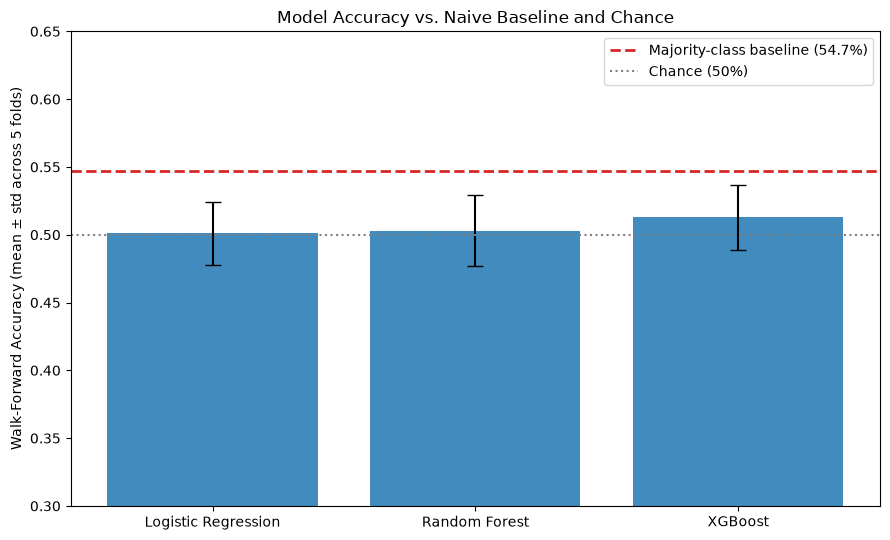

Saved final_model_comparison_chart.png to: D:\Projects\stock-market-prediction\data\final


In [11]:
baseline_acc = results_df.loc["Majority-Class Baseline", "Test Accuracy"]

fig, ax = plt.subplots(figsize=(9, 5.5))
models_plot = walkforward_summary.index.tolist()
means = walkforward_summary["Mean_Accuracy"].values
stds = walkforward_summary["Std_Accuracy"].values

ax.bar(models_plot, means, yerr=stds, capsize=6, color="tab:blue", alpha=0.85)
ax.axhline(baseline_acc, color="tab:red", linestyle="--", linewidth=2,
           label=f"Majority-class baseline ({baseline_acc:.1%})")
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1.5, label="Chance (50%)")

ax.set_ylabel("Walk-Forward Accuracy (mean ± std across 5 folds)")
ax.set_title("Model Accuracy vs. Naive Baseline and Chance")
ax.set_ylim(0.3, 0.65)
ax.legend()
plt.tight_layout()

fig.savefig(OUTPUT_DIR / "final_model_comparison_chart.png", dpi=150)
plt.show()

print("Saved final_model_comparison_chart.png to:", OUTPUT_DIR.resolve())


## 12. Discussion and Limitations


## 13. Final Step 5 Validation


In [12]:
print("=" * 60)
print("STEP 5 VALIDATION")
print("=" * 60)

print("\nFiles written to", OUTPUT_DIR.resolve(), ":")
for f in sorted(OUTPUT_DIR.glob("*")):
    print(" -", f.name)

print("\nConsolidated results table:")
display(final_summary.round(3))

print("\nWalk-forward summary (persisted, matches Step 4's displayed values):")
display(walkforward_summary)

print("\nStep 5 complete: results consolidated, diagnostics run, thesis discussion drafted.")
print("This is the final notebook in the pipeline.")


STEP 5 VALIDATION

Files written to D:\Projects\stock-market-prediction\data\final :
 - final_model_comparison_chart.png
 - thesis_final_results_summary.csv
 - walkforward_per_fold_v3.csv
 - walkforward_summary_v3.csv

Consolidated results table:


,Test Accuracy,Precision,Recall,F1,Walk-Forward Mean Accuracy,Walk-Forward Std,Train-Test Gap,Coverage,Accuracy_on_Confident_Days
Model,,,,,,,,,
Majority-Class Baseline,0.547,0.547,1.000,0.707,NaN,NaN,NaN,NaN,NaN
Logistic Regression,0.515,0.559,0.530,0.545,0.501,0.023,0.023,0.022,0.615
Random Forest,0.495,0.530,0.671,0.592,0.503,0.026,0.150,0.127,0.421
XGBoost,0.475,0.524,0.430,0.472,0.513,0.024,0.346,0.362,0.484



Walk-forward summary (persisted, matches Step 4's displayed values):


,Mean_Accuracy,Std_Accuracy,Min_Accuracy,Max_Accuracy
Logistic Regression,0.501,0.023,0.463,0.527
Random Forest,0.503,0.026,0.475,0.547
XGBoost,0.513,0.024,0.483,0.553



Step 5 complete: results consolidated, diagnostics run, thesis discussion drafted.
This is the final notebook in the pipeline.
